# Banca Virtuosa — Explainable AI for Image Classification

Banca Virtuosa deploys deep-learning models in processes subject to supervisory review. A model that
cannot justify a single decision is a compliance liability: an auditor asking *"why was this specific
document classified this way?"* needs an answer that points at the evidence in the input, not at an
accuracy score.

This notebook builds that answer trail end to end on a controlled task — **handwritten digit
classification (MNIST) with a pre-trained DenseNet-121** — and then explains its decisions with five
independent saliency techniques.

## 1. Environment & Reproducibility

The notebook is developed locally (Apple Silicon / MPS) and executed in full on Colab (CUDA). The
next cell installs only what is missing, so it is a no-op in an environment that already has the XAI
stack. Versions are pinned: an attribution map is only reproducible against the library that produced
it.

In [34]:
import importlib.util
import subprocess
import sys

# Pinned XAI stack. Present locally in the `mlenv` conda environment, missing on a fresh Colab VM.
XAI_REQUIREMENTS: dict[str, str] = {
    "captum": "captum==0.9.0",
    "lime": "lime==0.2.0.1",
    "shap": "shap==0.51.0",
}


def install_missing_packages(requirements: dict[str, str]) -> list[str]:
    """Pip-install the requirements whose import name is not resolvable. Returns what was installed."""
    missing = [spec for module, spec in requirements.items() if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    return missing


installed = install_missing_packages(XAI_REQUIREMENTS)
print(f"Installed: {installed}" if installed else "XAI stack already present, nothing to install.")

XAI stack already present, nothing to install.


In [35]:
import itertools
import json
import random
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Iterable, Optional

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.models import DenseNet121_Weights, densenet121

### Seeding

`set_seed` is called before data splitting, before model initialisation, and again before every XAI
method with internal sampling.

In [36]:
SEED: int = 42


def set_seed(seed: int = SEED) -> None:
    """Seed the Python, NumPy and Torch RNGs, including CUDA, for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_generator(seed: int = SEED) -> torch.Generator:
    """Return a seeded Torch generator, used to make DataLoader shuffling deterministic."""
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


set_seed()
print(f"Seed set to {SEED}")

Seed set to 42


### Configuration

A single frozen dataclass holds every knob, so the pipeline can be re-run identically or rescaled
without touching the code below. Two instances are defined:

- `PROTOTYPE_CONFIG` — a class-balanced subset, for developing the notebook on a laptop.
- `FULL_CONFIG` — the entire MNIST dataset, for the final Colab run.

Switching between them is a one-line change.

In [37]:
@dataclass(frozen=True)
class Config:
    """Every parameter of the Phase 0-1 pipeline. Frozen: use `replace(cfg, ...)` to derive a variant."""

    # --- reproducibility
    seed: int = SEED

    # --- data
    dataset_name: str = "MNIST"
    image_size: int = 224          # ImageNet-native; yields 7x7 Grad-CAM maps in Phase 2
    val_fraction: float = 0.15     # carved out of the official 60k training split
    n_train: Optional[int] = None  # None = use the whole split
    n_val: Optional[int] = None
    n_test: Optional[int] = None
    batch_size: int = 64           # image tensors through the backbone
    num_workers: int = 0

    # --- model
    model_name: str = "densenet121"
    num_classes: int = 10

    # --- classifier-head training (on cached embeddings)
    head_epochs: int = 300      # a cap, not a target: early stopping decides when to halt
    head_batch_size: int = 256
    head_lr: float = 1e-3
    weight_decay: float = 1e-4
    early_stopping_patience: int = 10

    # --- XAI case selection (Phase 1 output, consumed by Phase 2)
    n_correct_per_class: int = 3
    n_confusion_pairs: int = 5
    n_per_confusion_pair: int = 2

    # --- XAI cost knobs (Phase 2). SHAP is the expensive one: it samples one image at a time.
    ig_steps: int = 32
    occlusion_window: int = 32
    occlusion_stride: int = 16
    lime_samples: int = 200
    shap_background: int = 50
    shap_samples: int = 32


# Laptop prototyping: ~1.2k images per class in train, enough for a stable linear probe.
PROTOTYPE_CONFIG = Config(n_train=12_000, n_val=3_000, n_test=3_000, num_workers=0)

# Final Colab run: full MNIST, workers available, more sampling for the two stochastic techniques.
FULL_CONFIG = Config(n_train=None, n_val=None, n_test=None, num_workers=2, lime_samples=400, shap_samples=64)

CFG = FULL_CONFIG  # <-- switch to FULL_CONFIG for the final run
print(json.dumps(asdict(CFG), indent=2))

{
  "seed": 42,
  "dataset_name": "MNIST",
  "image_size": 224,
  "val_fraction": 0.15,
  "n_train": null,
  "n_val": null,
  "n_test": null,
  "batch_size": 64,
  "num_workers": 2,
  "model_name": "densenet121",
  "num_classes": 10,
  "head_epochs": 300,
  "head_batch_size": 256,
  "head_lr": 0.001,
  "weight_decay": 0.0001,
  "early_stopping_patience": 10,
  "n_correct_per_class": 3,
  "n_confusion_pairs": 5,
  "n_per_confusion_pair": 2,
  "ig_steps": 32,
  "occlusion_window": 32,
  "occlusion_stride": 16,
  "lime_samples": 400,
  "shap_background": 50,
  "shap_samples": 64
}


### Artifact layout

Everything the later phases need is written under a single root, addressed by relative paths.

```
BancaVirtuosa_Solution/
├── data/                     # MNIST download
└── outputs/
    ├── cache/                # frozen-backbone embeddings
    ├── checkpoints/          # model_best.pt
    ├── figures/              # report-ready figures
    ├── attributions/         # Phase 2 raw attribution arrays
    ├── config.json           # the config that produced all of the above
    ├── splits.json           # train/val/test index arrays
    └── selected_samples.json # the fixed XAI case set
```

In [38]:
def resolve_project_root() -> Path:
    """Project root: a Drive folder when running on Colab, the working directory otherwise."""
    if "google.colab" in sys.modules:
        from google.colab import drive

        drive.mount("/content/drive")
        return Path("/content/drive/MyDrive/BancaVirtuosa_Solution")
    return Path.cwd()


def build_directory_layout(root: Path) -> dict[str, Path]:
    """Create (if needed) and return the artifact directories used across all phases."""
    paths = {
        "root": root,
        "data": root / "data",
        "outputs": root / "outputs",
        "cache": root / "outputs" / "cache",
        "checkpoints": root / "outputs" / "checkpoints",
        "figures": root / "outputs" / "figures",
        "attributions": root / "outputs" / "attributions",
    }
    for path in paths.values():
        path.mkdir(parents=True, exist_ok=True)
    return paths


def save_json(payload: object, path: Path) -> None:
    """Write `payload` as indented JSON, for artifacts meant to be read by humans and by Phase 2."""
    path.write_text(json.dumps(payload, indent=2))
    print(f"Saved {path.relative_to(PATHS['root'])}")


PATHS = build_directory_layout(resolve_project_root())
save_json(asdict(CFG), PATHS["outputs"] / "config.json")
print(f"Project root: {PATHS['root']}")

Saved outputs/config.json
Project root: /Users/antonioponti/Desktop/AI Engineering/MachineLearningLab/Projects/BancaVirtuosa_Solution


### Device and plotting style

One device variable and one plotting style, both defined once. The chart palette is fixed here rather
than per figure: training and validation keep the same two colours in every plot, and all magnitude
encodings (the confusion matrix) use a single-hue light→dark blue ramp — never a rainbow, which would
imply an ordering the data does not have.

In [39]:
def select_device() -> torch.device:
    """Pick the best available accelerator: CUDA (Colab) > MPS (Apple Silicon) > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = select_device()
print(f"Device: {DEVICE}")

# --- fixed chart palette -------------------------------------------------
COLOR_TRAIN = "#2a78d6"   # blue
COLOR_VAL = "#eb6834"     # orange
COLOR_ERROR = "#e34948"   # red, reserved for misclassifications
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#52514e"
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "bv_blue", ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelcolor": INK_MUTED,
    "axes.edgecolor": "#d5d4d0",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#eceae6",
    "grid.linewidth": 0.8,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "legend.frameon": False,
})


def save_figure(fig: plt.Figure, name: str) -> None:
    """Persist a figure to outputs/figures so the report can be assembled without re-running cells."""
    fig.savefig(PATHS["figures"] / f"{name}.png")
    print(f"Saved figures/{name}.png")

Device: mps


## 2. Data Pipeline

MNIST ships as 60,000 training and 10,000 test images of 28×28 grayscale digits. DenseNet-121 expects
3×224×224 inputs, so the transform bridges the gap: resize, replicate the single channel three times,
normalise.

**Which statistics to normalise with?** MNIST's own are `mean 0.1307 / std 0.3081` (computed below for
the report). We use **ImageNet statistics** instead, deliberately: the backbone is frozen ImageNet
convolutions, and feeding them a distribution they were never calibrated on degrades the very features
we are about to reuse. The dataset's own statistics are reported as a dataset property; the
normalisation constants belong to the model.

In [40]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def build_transform(image_size: int) -> transforms.Compose:
    """Grayscale 28x28 PIL digit -> normalised 3 x image_size x image_size tensor for DenseNet."""
    return transforms.Compose([
        transforms.Resize(image_size),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def denormalize(image: torch.Tensor) -> np.ndarray:
    """Undo the ImageNet normalisation and return an HxWx3 array in [0, 1], for display only."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (image.detach().cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


TRANSFORM = build_transform(CFG.image_size)

mnist_train_full = MNIST(root=PATHS["data"], train=True, download=True, transform=TRANSFORM)
mnist_test_full = MNIST(root=PATHS["data"], train=False, download=True, transform=TRANSFORM)

# Dataset-level statistics on the raw uint8 images
raw_pixels = mnist_train_full.data.float() / 255.0
print(f"MNIST train: {len(mnist_train_full)} images | test: {len(mnist_test_full)} images")
print(f"Raw image shape: {tuple(mnist_train_full.data.shape[1:])} grayscale")
print(f"Dataset statistics: mean={raw_pixels.mean():.4f}, std={raw_pixels.std():.4f}")
print(f"Transformed tensor: {tuple(mnist_train_full[0][0].shape)}")

MNIST train: 60000 images | test: 10000 images
Raw image shape: (28, 28) grayscale
Dataset statistics: mean=0.1307, std=0.3081
Transformed tensor: (3, 224, 224)


### Stratified splits

MNIST has no official validation split, so one is carved out of the 60k training images. Both the
split and the optional subsetting are **stratified** — class proportions are preserved — and both are
driven by `CFG.seed`, so the prototype run and the full run draw from the same underlying partition
(the prototype's training set is a subset of the full one; nothing leaks across the boundary).

In [41]:
def stratified_subset(indices: np.ndarray, targets: np.ndarray, n_samples: Optional[int],
                      seed: int) -> np.ndarray:
    """
    Draw a class-balanced random subset of `indices`, keeping `n_samples // n_classes` per class.

    Returns `indices` unchanged when `n_samples` is None or exceeds what is available, so the same
    call site serves both the prototype and the full-dataset configuration.
    """
    if n_samples is None or n_samples >= len(indices):
        return indices
    classes = np.unique(targets[indices])
    per_class = n_samples // len(classes)
    rng = np.random.default_rng(seed)
    selected = [
        rng.permutation(indices[targets[indices] == label])[:per_class] for label in classes
    ]
    return np.sort(np.concatenate(selected))


def build_splits(cfg: Config, train_targets: np.ndarray,
                 test_targets: np.ndarray) -> dict[str, np.ndarray]:
    """
    Produce stratified train/val/test index arrays.

    Validation is split out of the official training set; test is the official test set. Each split is
    then optionally subsampled in a class-balanced way according to the config.
    """
    train_positions, val_positions = train_test_split(
        np.arange(len(train_targets)),
        test_size=cfg.val_fraction,
        stratify=train_targets,
        random_state=cfg.seed,
    )
    return {
        "train": stratified_subset(np.sort(train_positions), train_targets, cfg.n_train, cfg.seed),
        "val": stratified_subset(np.sort(val_positions), train_targets, cfg.n_val, cfg.seed),
        "test": stratified_subset(np.arange(len(test_targets)), test_targets, cfg.n_test, cfg.seed),
    }


def class_distribution(targets: np.ndarray, indices: np.ndarray, num_classes: int) -> np.ndarray:
    """Count samples per class within a split."""
    return np.bincount(targets[indices], minlength=num_classes)


set_seed(CFG.seed)
train_targets = mnist_train_full.targets.numpy()
test_targets = mnist_test_full.targets.numpy()
SPLITS = build_splits(CFG, train_targets, test_targets)

datasets: dict[str, Subset] = {
    "train": Subset(mnist_train_full, SPLITS["train"].tolist()),
    "val": Subset(mnist_train_full, SPLITS["val"].tolist()),
    "test": Subset(mnist_test_full, SPLITS["test"].tolist()),
}

split_targets = {
    "train": train_targets, "val": train_targets, "test": test_targets,
}
distributions = {
    name: class_distribution(split_targets[name], indices, CFG.num_classes)
    for name, indices in SPLITS.items()
}
for name, counts in distributions.items():
    print(f"{name:>5}: {counts.sum():>6} images | per class {counts.tolist()}")

save_json({name: indices.tolist() for name, indices in SPLITS.items()},
          PATHS["outputs"] / "splits.json")

train:  51000 images | per class [5035, 5731, 5064, 5211, 4966, 4608, 5030, 5325, 4973, 5057]
  val:   9000 images | per class [888, 1011, 894, 920, 876, 813, 888, 940, 878, 892]
 test:  10000 images | per class [980, 1135, 1032, 1010, 982, 892, 958, 1028, 974, 1009]
Saved outputs/splits.json


A look at the class balance and at what the network will actually receive as input.

Saved figures/01_class_distribution.png


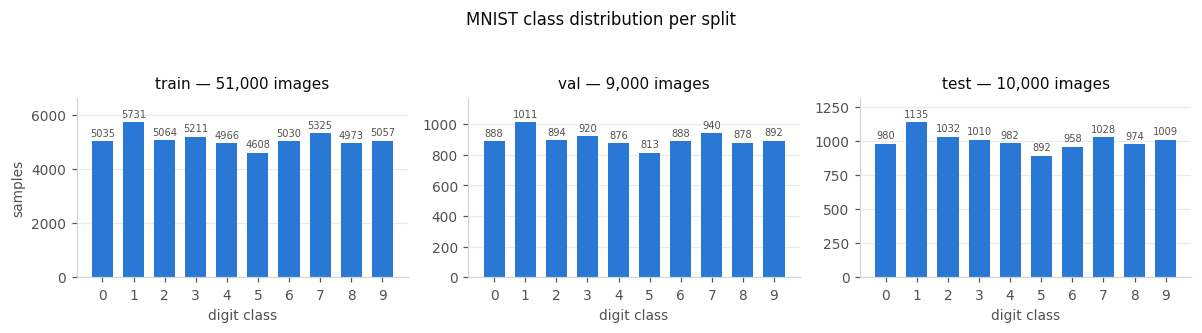

Saved figures/02_input_samples.png


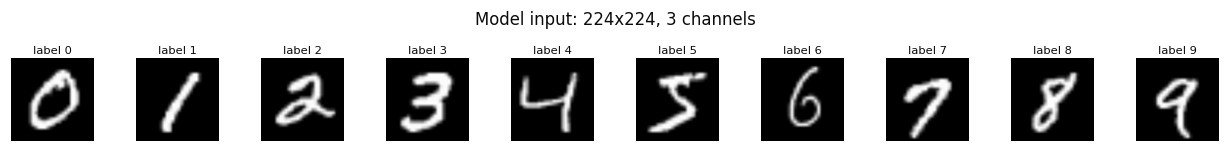

In [42]:
def plot_class_distribution(distributions: dict[str, np.ndarray]) -> plt.Figure:
    """One panel per split: samples per class. Single series each, so values are labelled directly."""
    fig, axes = plt.subplots(1, len(distributions), figsize=(11, 2.8))
    for ax, (name, counts) in zip(axes, distributions.items()):
        bars = ax.bar(np.arange(len(counts)), counts, color=COLOR_TRAIN, width=0.68)
        ax.bar_label(bars, fmt="%d", fontsize=6.5, color=INK_MUTED, padding=2)
        ax.set_title(f"{name} — {counts.sum():,} images", color=INK_PRIMARY)
        ax.set_xlabel("digit class")
        ax.set_xticks(np.arange(len(counts)))
        ax.set_axisbelow(True)
        ax.xaxis.grid(False)
        ax.margins(y=0.16)
    axes[0].set_ylabel("samples")
    fig.suptitle("MNIST class distribution per split", color=INK_PRIMARY, y=1.06)
    fig.tight_layout()
    return fig


def plot_sample_grid(dataset: Dataset, indices: Iterable[int], titles: Iterable[str],
                     n_cols: int = 10, title: str = "") -> plt.Figure:
    """
    Show model-space images (de-normalised) in a grid. Reused for the input preview, for the
    selected correct cases and for the misclassified cases.
    """
    indices, titles = list(indices), list(titles)
    n_rows = int(np.ceil(len(indices) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.15, n_rows * 1.32))
    for ax, position, label in zip(np.atleast_1d(axes).ravel(), indices, titles):
        image, _ = dataset[position]
        ax.imshow(denormalize(image), cmap="gray")
        ax.set_title(label, fontsize=7.5, color=INK_PRIMARY, pad=3)
    for ax in np.atleast_1d(axes).ravel():
        ax.set_axis_off()
    if title:
        fig.suptitle(title, color=INK_PRIMARY, y=1.0)
    fig.tight_layout()
    return fig


fig = plot_class_distribution(distributions)
save_figure(fig, "01_class_distribution")
plt.show()

# One example per class, exactly as the network sees it after resize + 3-channel replication.
preview_positions = [int(np.flatnonzero(train_targets[SPLITS["train"]] == digit)[0])
                     for digit in range(CFG.num_classes)]
fig = plot_sample_grid(datasets["train"], preview_positions,
                       [f"label {digit}" for digit in range(CFG.num_classes)],
                       title=f"Model input: {CFG.image_size}x{CFG.image_size}, 3 channels")
save_figure(fig, "02_input_samples")
plt.show()

In [43]:
def make_dataloader(dataset: Dataset, cfg: Config) -> DataLoader:
    """Build an unshuffled image DataLoader: order must match the cached embeddings and the indices."""
    return DataLoader(dataset, batch_size=cfg.batch_size, shuffle=False,
                      num_workers=cfg.num_workers, pin_memory=(DEVICE.type == "cuda"))


loaders = {name: make_dataloader(dataset, CFG) for name, dataset in datasets.items()}
print({name: len(loader) for name, loader in loaders.items()}, "batches per split")

{'train': 797, 'val': 141, 'test': 157} batches per split


## 3. Pre-trained Model

`densenet121` with ImageNet weights: its final feature map aggregates features from every earlier
layer in the block, which is the signal Grad-CAM reads.

The 1000-class classifier is replaced by a 10-class linear layer and the backbone is **frozen**.

In [44]:
def build_model(cfg: Config, freeze_backbone: bool = True) -> nn.Module:
    """Load ImageNet-pretrained DenseNet-121 and swap in a `cfg.num_classes` classifier head."""
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    model.classifier = nn.Linear(model.classifier.in_features, cfg.num_classes)
    if freeze_backbone:
        for parameter in model.features.parameters():
            parameter.requires_grad = False
    return model


def describe_model(model: nn.Module, name: str) -> None:
    """Log the parameter budget: total, trainable and frozen."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: {total:,} parameters | trainable {trainable:,} "
          f"({100 * trainable / total:.3f}%) | frozen {total - trainable:,}")


set_seed(CFG.seed)
model = build_model(CFG).to(DEVICE)
describe_model(model, CFG.model_name)
print(f"Classifier head: {model.classifier}")

densenet121: 6,964,106 parameters | trainable 10,250 (0.147%) | frozen 6,953,856
Classifier head: Linear(in_features=1024, out_features=10, bias=True)


### Caching the frozen embeddings

With a frozen backbone, `head_epochs` epochs of training would push
every image through DenseNet `head_epochs` times to compute an identical result. Instead each split is
pushed through **once**, the 1024-d pooled embeddings are stored on disk, and the head is trained on
those tensors.

`pooled_features` mirrors `DenseNet.forward` exactly (ReLU → global average pool → flatten) so the
head trained on cached vectors is bit-for-bit the head the assembled model uses.

In [45]:
def pooled_features(model: nn.Module, images: torch.Tensor) -> torch.Tensor:
    """
    Backbone embedding, computed exactly as `DenseNet.forward` does before the classifier.

    Keeping this in one function guarantees the cached vectors and the live model agree.
    """
    features = model.features(images)
    features = F.relu(features, inplace=True)
    features = F.adaptive_avg_pool2d(features, (1, 1))
    return torch.flatten(features, 1)


def extract_features(model: nn.Module, loader: DataLoader, device: torch.device,
                     log_every: int = 25) -> tuple[torch.Tensor, torch.Tensor]:
    """Run the frozen backbone over a loader and return (embeddings, labels) on the CPU."""
    model.eval()
    embeddings, labels = [], []
    started = time.time()
    with torch.inference_mode():
        for batch_number, (images, targets) in enumerate(loader, start=1):
            embeddings.append(pooled_features(model, images.to(device)).cpu())
            labels.append(targets)
            if batch_number % log_every == 0 or batch_number == len(loader):
                done = min(batch_number * loader.batch_size, len(loader.dataset))
                rate = done / (time.time() - started)
                print(f"    {done}/{len(loader.dataset)} images ({rate:.0f} img/s)")
    return torch.cat(embeddings), torch.cat(labels)


def cached_features(name: str, model: nn.Module, loader: DataLoader, cfg: Config,
                    device: torch.device) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Load the split's embeddings from disk, computing and caching them on a miss.

    The cache key includes the split size and image size, so changing the config cannot silently
    reuse embeddings computed for a different pipeline.
    """
    cache_file = PATHS["cache"] / f"{name}_{cfg.model_name}_{cfg.image_size}px_{len(loader.dataset)}.pt"
    if cache_file.exists():
        payload = torch.load(cache_file)
        print(f"  {name}: loaded cache {cache_file.name}")
        return payload["features"], payload["labels"]
    print(f"  {name}: extracting {len(loader.dataset)} embeddings...")
    features, labels = extract_features(model, loader, device)
    torch.save({"features": features, "labels": labels}, cache_file)
    print(f"  {name}: cached to {cache_file.name}")
    return features, labels

In [46]:
%%time
set_seed(CFG.seed)
embeddings = {name: cached_features(name, model, loader, CFG, DEVICE)
              for name, loader in loaders.items()}
for name, (features, labels) in embeddings.items():
    print(f"{name:>5}: features {tuple(features.shape)} | labels {tuple(labels.shape)}")

  train: loaded cache train_densenet121_224px_51000.pt
  val: loaded cache val_densenet121_224px_9000.pt
  test: loaded cache test_densenet121_224px_10000.pt
train: features (51000, 1024) | labels (51000,)
  val: features (9000, 1024) | labels (9000,)
 test: features (10000, 1024) | labels (10000,)
CPU times: user 4.26 ms, sys: 109 ms, total: 113 ms
Wall time: 383 ms


## 4. Training the Classifier Head

The head is trained on the cached embeddings with early stopping on validation loss. `run_epoch` is
written once and serves both training (optimizer given) and evaluation (optimizer omitted) — the same
function is reused by the optional end-to-end stage further down, so there is no second, subtly
different loop to keep in sync.

In [47]:
def run_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device,
              optimizer: Optional[torch.optim.Optimizer] = None) -> tuple[float, float]:
    """
    One pass over `loader`, returning (mean loss, accuracy).

    Trains when an `optimizer` is supplied, evaluates under `no_grad` otherwise.
    """
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, correct, seen = 0.0, 0, 0
    with torch.set_grad_enabled(is_training):
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs)
            loss = criterion(logits, targets)
            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * targets.size(0)
            correct += (logits.argmax(dim=1) == targets).sum().item()
            seen += targets.size(0)
    return total_loss / seen, correct / seen


def train_with_early_stopping(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
                              optimizer: torch.optim.Optimizer, device: torch.device, epochs: int,
                              patience: int, log_every: int = 20,
                              ) -> tuple[dict[str, list[float]], dict[str, torch.Tensor]]:
    """
    Train `model`, tracking the best validation loss and stopping after `patience` epochs without
    improvement.

    `epochs` is an upper bound; early stopping decides the actual length. Returns the metric history
    and the best epoch's state dict.
    """
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_loss, best_acc, best_epoch, best_state = np.inf, 0.0, 0, None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, device, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_loss:
            best_loss, best_acc, best_epoch, epochs_without_improvement = val_loss, val_acc, epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        stopping = epochs_without_improvement >= patience
        if epoch % log_every == 0 or epoch == epochs or stopping:
            print(f"  epoch {epoch:>3}/{epochs} | train {train_loss:.4f}/{train_acc:.4f} "
                  f"| val {val_loss:.4f}/{val_acc:.4f}")
        if stopping:
            print(f"  early stop: no val-loss improvement for {patience} epochs")
            break

    model.load_state_dict(best_state)
    print(f"  best epoch {best_epoch}: val loss {best_loss:.4f}, "
          f"val accuracy {best_acc:.4f} (weights restored)")
    return history, best_state


def make_embedding_loaders(embeddings: dict[str, tuple[torch.Tensor, torch.Tensor]],
                           cfg: Config) -> dict[str, DataLoader]:
    """Wrap the cached (features, labels) tensors in DataLoaders for head training."""
    return {
        name: DataLoader(
            TensorDataset(features, labels),
            batch_size=cfg.head_batch_size,
            shuffle=(name == "train"),
            generator=make_generator(cfg.seed) if name == "train" else None,
        )
        for name, (features, labels) in embeddings.items()
    }

In [48]:
%%time
set_seed(CFG.seed)

embedding_loaders = make_embedding_loaders(embeddings, CFG)
head = nn.Linear(embeddings["train"][0].shape[1], CFG.num_classes).to(DEVICE)
optimizer = torch.optim.Adam(head.parameters(), lr=CFG.head_lr, weight_decay=CFG.weight_decay)

print("Training the classifier head on cached embeddings")
history, best_head_state = train_with_early_stopping(
    head, embedding_loaders["train"], embedding_loaders["val"], optimizer, DEVICE,
    epochs=CFG.head_epochs, patience=CFG.early_stopping_patience,
)

# Transplant the trained head into the full model
model.classifier.load_state_dict(best_head_state)
model = model.to(DEVICE)

Training the classifier head on cached embeddings
  epoch  20/300 | train 0.0789/0.9776 | val 0.0962/0.9706
  epoch  40/300 | train 0.0621/0.9826 | val 0.0841/0.9750
  epoch  60/300 | train 0.0559/0.9843 | val 0.0811/0.9743
  epoch  80/300 | train 0.0538/0.9849 | val 0.0806/0.9752
  epoch 100/300 | train 0.0522/0.9859 | val 0.0820/0.9742
  epoch 101/300 | train 0.0521/0.9852 | val 0.0790/0.9756
  early stop: no val-loss improvement for 10 epochs
  best epoch 91: val loss 0.0787, val accuracy 0.9760 (weights restored)
CPU times: user 30.2 s, sys: 6.73 s, total: 37 s
Wall time: 54 s


Saved model_best.pt (28.5 MB)
Saved figures/03_training_curves.png


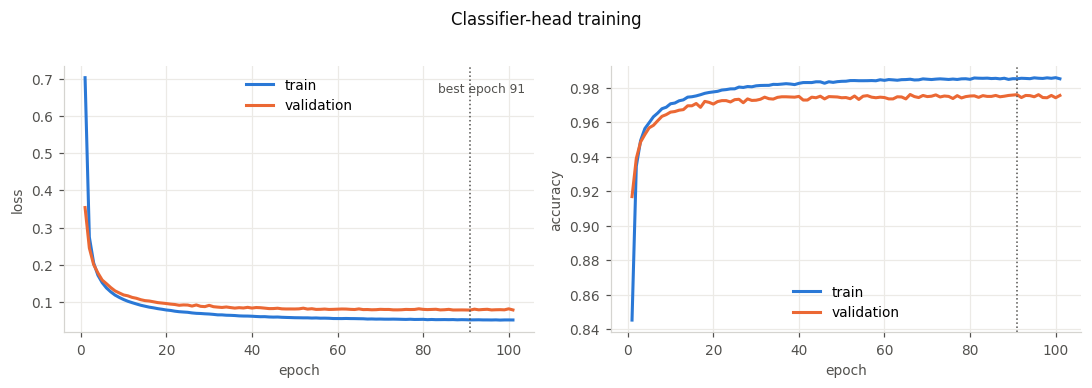

In [49]:
def save_checkpoint(model: nn.Module, cfg: Config, history: dict[str, list[float]], path: Path) -> None:
    """Persist weights together with the config and curves that produced them."""
    torch.save({"state_dict": model.state_dict(), "config": asdict(cfg), "history": history}, path)
    print(f"Saved {path.name} ({path.stat().st_size / 1e6:.1f} MB)")


def plot_training_curves(history: dict[str, list[float]]) -> plt.Figure:
    """Loss and accuracy per epoch, train vs validation. Two series, so both are labelled."""
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    best_epoch = int(np.argmin(history["val_loss"])) + 1
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    panels = [("loss", "train_loss", "val_loss"), ("accuracy", "train_acc", "val_acc")]
    for ax, (ylabel, train_key, val_key) in zip(axes, panels):
        ax.plot(epochs, history[train_key], color=COLOR_TRAIN, linewidth=2, label="train")
        ax.plot(epochs, history[val_key], color=COLOR_VAL, linewidth=2, label="validation")
        ax.axvline(best_epoch, color=INK_MUTED, linestyle=":", linewidth=1)
        ax.set_xlabel("epoch")
        ax.set_ylabel(ylabel)
        ax.set_axisbelow(True)
        ax.legend(loc="best")
    axes[0].annotate(f"best epoch {best_epoch}", xy=(0.98, 0.9), xycoords="axes fraction",
                     ha="right", fontsize=8, color=INK_MUTED)
    fig.suptitle("Classifier-head training", color=INK_PRIMARY, y=1.02)
    fig.tight_layout()
    return fig


save_checkpoint(model, CFG, history, PATHS["checkpoints"] / "model_best.pt")
fig = plot_training_curves(history)
save_figure(fig, "03_training_curves")
plt.show()

## 5. Evaluation


In [50]:
def predict(model: nn.Module, loader: DataLoader, device: torch.device) -> dict[str, np.ndarray]:
    """Run the full model over a loader, returning logits, probabilities, predictions and labels."""
    model.eval()
    logits, labels = [], []
    with torch.inference_mode():
        for images, targets in loader:
            logits.append(model(images.to(device)).cpu())
            labels.append(targets)
    logits = torch.cat(logits)
    return {
        "logits": logits.numpy(),
        "probabilities": F.softmax(logits, dim=1).numpy(),
        "predictions": logits.argmax(dim=1).numpy(),
        "labels": torch.cat(labels).numpy(),
    }


%time test_outputs = predict(model, loaders["test"], DEVICE)

# Consistency check: the assembled model must reproduce the cached-embedding head exactly.
with torch.inference_mode():
    cached_predictions = model.classifier(embeddings["test"][0].to(DEVICE)).argmax(dim=1).cpu().numpy()
agreement = (cached_predictions == test_outputs["predictions"]).mean()
print(f"Cached-embedding vs full-model agreement: {agreement:.6f} (expected 1.0)")

test_accuracy = accuracy_score(test_outputs["labels"], test_outputs["predictions"])
print(f"\nTest accuracy: {test_accuracy:.4f} on {len(test_outputs['labels']):,} images")
print(classification_report(test_outputs["labels"], test_outputs["predictions"], digits=4))

CPU times: user 9.55 s, sys: 6.17 s, total: 15.7 s
Wall time: 1min 36s
Cached-embedding vs full-model agreement: 1.000000 (expected 1.0)

Test accuracy: 0.9726 on 10,000 images
              precision    recall  f1-score   support

           0     0.9839    0.9949    0.9893       980
           1     0.9835    0.9956    0.9895      1135
           2     0.9730    0.9419    0.9572      1032
           3     0.9516    0.9743    0.9628      1010
           4     0.9817    0.9847    0.9832       982
           5     0.9361    0.9361    0.9361       892
           6     0.9770    0.9770    0.9770       958
           7     0.9757    0.9776    0.9767      1028
           8     0.9773    0.9733    0.9753       974
           9     0.9819    0.9653    0.9735      1009

    accuracy                         0.9726     10000
   macro avg     0.9722    0.9721    0.9721     10000
weighted avg     0.9726    0.9726    0.9726     10000



Saved figures/04_confusion_matrix.png


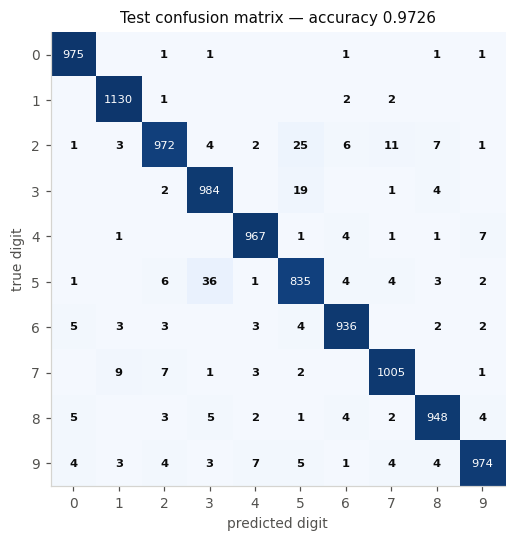

,precision,recall,f1-score,support
digit,,,,
0,0.9839,0.9949,0.9893,980.0
1,0.9835,0.9956,0.9895,1135.0
2,0.9730,0.9419,0.9572,1032.0
3,0.9516,0.9743,0.9628,1010.0
4,0.9817,0.9847,0.9832,982.0
5,0.9361,0.9361,0.9361,892.0
6,0.9770,0.9770,0.9770,958.0
7,0.9757,0.9776,0.9767,1028.0
8,0.9773,0.9733,0.9753,974.0


In [51]:
def plot_confusion_matrix(labels: np.ndarray, predictions: np.ndarray, num_classes: int) -> plt.Figure:
    """
    Confusion matrix with a single-hue sequential ramp (counts are magnitudes, not categories).

    Row-normalised for colour so that colour reads as recall regardless of class size; the annotation
    is the absolute count, and only non-zero cells are annotated to keep the grid readable.
    """
    matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
    normalized = matrix / matrix.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(5.6, 5))
    ax.imshow(normalized, cmap=BLUE_RAMP, vmin=0, vmax=1)
    for row in range(num_classes):
        for column in range(num_classes):
            count = matrix[row, column]
            if count == 0:
                continue
            on_diagonal = row == column
            ax.text(column, row, f"{count}", ha="center", va="center", fontsize=7.5,
                    color="#ffffff" if normalized[row, column] > 0.55 else INK_PRIMARY,
                    fontweight="bold" if not on_diagonal else "normal")
    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xlabel("predicted digit")
    ax.set_ylabel("true digit")
    ax.set_title(f"Test confusion matrix — accuracy {accuracy_score(labels, predictions):.4f}",
                 color=INK_PRIMARY)
    ax.grid(False)
    fig.tight_layout()
    return fig


def per_class_report(labels: np.ndarray, predictions: np.ndarray) -> pd.DataFrame:
    """Per-class precision/recall/F1/support as a table, for the Phase 3 report."""
    report = classification_report(labels, predictions, output_dict=True, digits=4)
    rows = {key: value for key, value in report.items() if key.isdigit()}
    return pd.DataFrame(rows).T.rename_axis("digit")


fig = plot_confusion_matrix(test_outputs["labels"], test_outputs["predictions"], CFG.num_classes)
save_figure(fig, "04_confusion_matrix")
plt.show()

display(per_class_report(test_outputs["labels"], test_outputs["predictions"]).round(4))

## 6. Fixed Case Set for the XAI Phase

All five techniques will run on **one fixed, seeded set of test images**, chosen now:

- **Correct cases** — `n_correct_per_class` per digit, sampled from the correctly classified pool.
  Class-balanced by construction, so no digit dominates the visual comparison.
- **Incorrect cases** — drawn from the *most frequent confusion pairs* rather than at random. A random
  error sample would mostly show one-off oddities; the frequent pairs are the model's systematic
  weaknesses.

In [52]:
def top_confusion_pairs(labels: np.ndarray, predictions: np.ndarray, n_pairs: int,
                        num_classes: int) -> list[tuple[int, int, int]]:
    """Most frequent (true, predicted) off-diagonal pairs, as (true, predicted, count), descending."""
    matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
    np.fill_diagonal(matrix, 0)
    flat_order = np.argsort(matrix, axis=None)[::-1]
    pairs = [(int(t), int(p), int(matrix[t, p]))
             for t, p in (np.unravel_index(index, matrix.shape) for index in flat_order)
             if matrix[t, p] > 0]
    return pairs[:n_pairs]


def select_xai_cases(outputs: dict[str, np.ndarray], test_indices: np.ndarray,
                     cfg: Config) -> dict[str, object]:
    """
    Build the fixed case set: class-balanced correct predictions plus errors from the top confusion
    pairs.

    Positions are indices into the test *split*; `mnist_index` is the index into the official MNIST
    test set. Sampling uses `cfg.seed`, so the selection is identical on every run.
    """
    labels, predictions = outputs["labels"], outputs["predictions"]
    confidences = outputs["probabilities"].max(axis=1)
    rng = np.random.default_rng(cfg.seed)

    def describe(position: int) -> dict[str, object]:
        return {
            "position": int(position),
            "mnist_index": int(test_indices[position]),
            "true": int(labels[position]),
            "predicted": int(predictions[position]),
            "confidence": round(float(confidences[position]), 4),
        }

    correct = {}
    for digit in range(cfg.num_classes):
        pool = np.flatnonzero((labels == digit) & (predictions == labels))
        chosen = rng.permutation(pool)[:cfg.n_correct_per_class]
        correct[str(digit)] = [describe(position) for position in np.sort(chosen)]

    pairs = top_confusion_pairs(labels, predictions, cfg.n_confusion_pairs, cfg.num_classes)
    incorrect = {}
    for true_digit, predicted_digit, count in pairs:
        pool = np.flatnonzero((labels == true_digit) & (predictions == predicted_digit))
        chosen = rng.permutation(pool)[:cfg.n_per_confusion_pair]
        incorrect[f"{true_digit}->{predicted_digit}"] = {
            "pair_frequency": count,
            "cases": [describe(position) for position in np.sort(chosen)],
        }

    n_correct = sum(len(cases) for cases in correct.values())
    n_incorrect = sum(len(entry["cases"]) for entry in incorrect.values())
    return {
        "seed": cfg.seed,
        "split": "test",
        "n_correct": n_correct,
        "n_incorrect": n_incorrect,
        "confusion_pairs": [{"true": t, "predicted": p, "count": c} for t, p, c in pairs],
        "correct": correct,
        "incorrect": incorrect,
    }


set_seed(CFG.seed)
selected_cases = select_xai_cases(test_outputs, SPLITS["test"], CFG)

print("Top confusion pairs (true -> predicted, count):")
for pair in selected_cases["confusion_pairs"]:
    print(f"  {pair['true']} -> {pair['predicted']}: {pair['count']}")
print(f"\nSelected {selected_cases['n_correct']} correct and "
      f"{selected_cases['n_incorrect']} misclassified cases "
      f"= {selected_cases['n_correct'] + selected_cases['n_incorrect']} images for Phase 2.")

save_json(selected_cases, PATHS["outputs"] / "selected_samples.json")

Top confusion pairs (true -> predicted, count):
  5 -> 3: 36
  2 -> 5: 25
  3 -> 5: 19
  2 -> 7: 11
  7 -> 1: 9

Selected 30 correct and 10 misclassified cases = 40 images for Phase 2.
Saved outputs/selected_samples.json


Saved figures/05_selected_correct.png


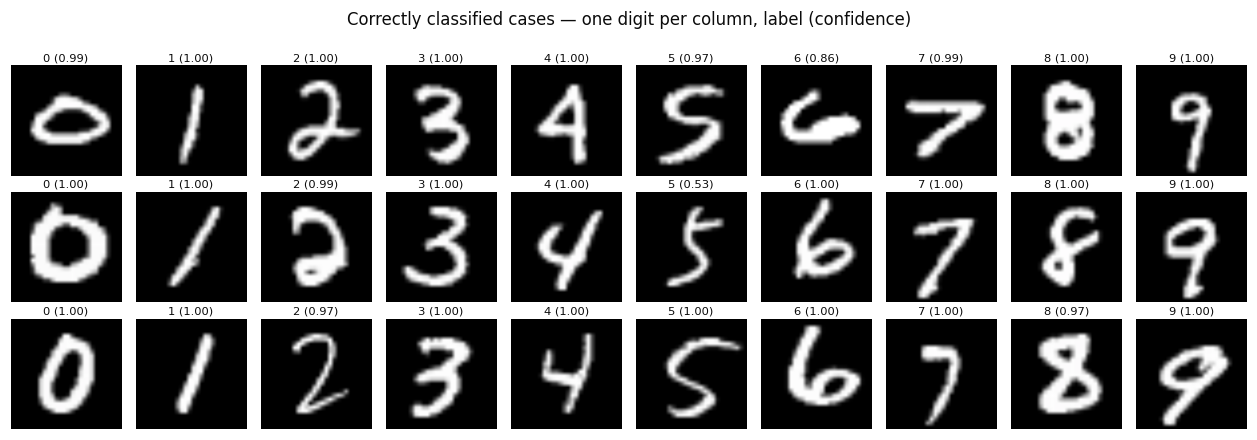

Saved figures/06_selected_incorrect.png


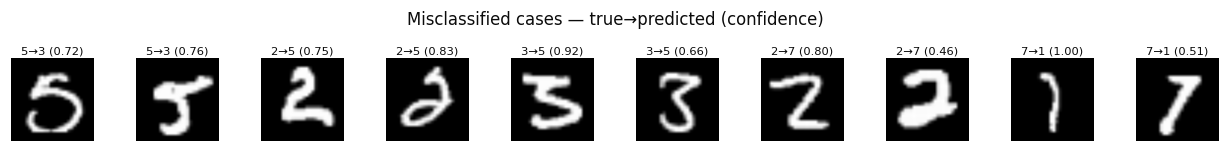

In [53]:
def flatten_cases(selection: dict[str, object], num_classes: int) -> tuple[list[dict], list[dict]]:
    """
    Flatten the nested selection into (correct, incorrect) lists.

    Correct cases are ordered rank-major so that a `num_classes`-column grid puts one digit per
    column; incorrect cases follow the confusion-pair order (most frequent first).
    """
    per_digit = selection["correct"]
    n_ranks = max(len(cases) for cases in per_digit.values())
    correct = [per_digit[str(digit)][rank]
               for rank in range(n_ranks)
               for digit in range(num_classes) if rank < len(per_digit[str(digit)])]
    incorrect = [case for entry in selection["incorrect"].values() for case in entry["cases"]]
    return correct, incorrect


correct_cases, incorrect_cases = flatten_cases(selected_cases, CFG.num_classes)

fig = plot_sample_grid(
    datasets["test"],
    [case["position"] for case in correct_cases],
    [f"{case['true']} ({case['confidence']:.2f})" for case in correct_cases],
    n_cols=CFG.num_classes,
    title="Correctly classified cases — one digit per column, label (confidence)",
)
save_figure(fig, "05_selected_correct")
plt.show()

if incorrect_cases:
    fig = plot_sample_grid(
        datasets["test"],
        [case["position"] for case in incorrect_cases],
        [f"{case['true']}→{case['predicted']} ({case['confidence']:.2f})"
         for case in incorrect_cases],
        n_cols=min(len(incorrect_cases), CFG.n_per_confusion_pair * CFG.n_confusion_pairs),
        title="Misclassified cases — true→predicted (confidence)",
    )
    save_figure(fig, "06_selected_incorrect")
    plt.show()
else:
    print("No misclassifications on the test split: Phase 3's error analysis needs a weaker model.")

## 8. Saliency Maps

Five techniques on the 40 cases selected above.

In [54]:
def build_case_batch(cases: list[dict], dataset: Dataset,
                     device: torch.device) -> tuple[torch.Tensor, torch.Tensor]:
    """Stack the selected cases into one batch of model-space images plus their predicted classes."""
    images = torch.stack([dataset[case["position"]][0] for case in cases])
    predicted = torch.tensor([case["predicted"] for case in cases])
    return images.to(device), predicted.to(device)


CASES = correct_cases + incorrect_cases
case_images, case_targets = build_case_batch(CASES, datasets["test"], DEVICE)

# The batch must reproduce the predictions recorded in Phase 1, or the maps would explain something else.
with torch.inference_mode():
    live_predictions = model(case_images).argmax(dim=1)
print(f"Case batch: {tuple(case_images.shape)}")
print(f"Predictions match Phase 1: {bool((live_predictions == case_targets).all())}")

Case batch: (40, 3, 224, 224)
Predictions match Phase 1: True


In [55]:
def black_baseline(like: torch.Tensor) -> torch.Tensor:
    """Pixel value 0 (MNIST background) in model space — the 'no ink' reference."""
    mean = torch.tensor(IMAGENET_MEAN, device=like.device).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=like.device).view(1, 3, 1, 1)
    return ((torch.zeros_like(like) - mean) / std)


def channel_sum(attribution: torch.Tensor) -> np.ndarray:
    """Collapse the 3 replicated channels into one signed (N, H, W) map."""
    return attribution.sum(dim=1).detach().cpu().numpy()


def predict_display_space(images_hwc: np.ndarray) -> np.ndarray:
    """
    Class probabilities for HxWx3 images in [0, 1] display space.

    LIME perturbs images in display space, so this is the adapter back to model space. It applies the
    same normalisation as the training transform, keeping one inference path for every technique.
    """
    tensor = torch.from_numpy(np.asarray(images_hwc)).float().permute(0, 3, 1, 2)
    mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
    with torch.inference_mode():
        logits = model(((tensor - mean) / std).to(DEVICE))
    return F.softmax(logits, dim=1).cpu().numpy()

In [56]:
from captum.attr import IntegratedGradients, LayerAttribution, LayerGradCam, Occlusion


def attribute_gradcam(images: torch.Tensor, targets: torch.Tensor, cfg: Config) -> np.ndarray:
    """Grad-CAM on the last dense block, bilinearly upsampled from 7x7 to input resolution."""
    explainer = LayerGradCam(model, model.features.denseblock4)
    attribution = explainer.attribute(images, target=targets, relu_attributions=True)
    return channel_sum(LayerAttribution.interpolate(attribution, images.shape[-2:], "bilinear"))


def attribute_integrated_gradients(images: torch.Tensor, targets: torch.Tensor,
                                   cfg: Config) -> np.ndarray:
    """Integrated Gradients along the straight path from the black baseline to the image."""
    explainer = IntegratedGradients(model)
    attribution = explainer.attribute(images, baselines=black_baseline(images), target=targets,
                                      n_steps=cfg.ig_steps, internal_batch_size=cfg.batch_size)
    return channel_sum(attribution)


def attribute_occlusion(images: torch.Tensor, targets: torch.Tensor, cfg: Config) -> np.ndarray:
    """Occlusion: slide a square patch of black baseline over the image and watch the logit move."""
    explainer = Occlusion(model)
    attribution = explainer.attribute(
        images, target=targets, baselines=black_baseline(images),
        sliding_window_shapes=(3, cfg.occlusion_window, cfg.occlusion_window),
        strides=(3, cfg.occlusion_stride, cfg.occlusion_stride),
        perturbations_per_eval=8,
    )
    return channel_sum(attribution)

In [57]:
import contextlib
import io

import shap
from lime import lime_image


def attribute_lime(images: torch.Tensor, targets: torch.Tensor, cfg: Config) -> np.ndarray:
    """
    LIME superpixel weights, painted back onto the segmentation so the output is a dense map like
    the other four techniques.

    `hide_color=0` blacks out the hidden superpixels, matching the black baseline used elsewhere.
    LIME has no batch API, so this loops; its tqdm bar is suppressed to keep the notebook readable.
    """
    explainer = lime_image.LimeImageExplainer(random_state=cfg.seed)
    maps = []
    for image, target in zip(images, targets.tolist()):
        with contextlib.redirect_stderr(io.StringIO()):
            explanation = explainer.explain_instance(
                denormalize(image).astype(np.double), predict_display_space,
                labels=(target,), top_labels=None, hide_color=0,
                num_samples=cfg.lime_samples, batch_size=cfg.batch_size, random_seed=cfg.seed,
            )
        weights = np.zeros(explanation.segments.shape)
        for segment_id, weight in explanation.local_exp[target]:
            weights[explanation.segments == segment_id] = weight
        maps.append(weights)
    return np.stack(maps)


def shap_background(cfg: Config) -> torch.Tensor:
    """
    A fixed, class-balanced background set drawn from the training split.

    SHAP attributions are relative to this reference distribution, so it is built once, deterministically,
    and shared by every SHAP call — the plan's cost-bounding measure.
    """
    per_class = cfg.shap_background // cfg.num_classes
    subset_targets = train_targets[SPLITS["train"]]
    positions = np.concatenate([np.flatnonzero(subset_targets == digit)[:per_class]
                                for digit in range(cfg.num_classes)])
    return torch.stack([datasets["train"][int(position)][0] for position in positions])


def attribute_shap(images: torch.Tensor, targets: torch.Tensor, cfg: Config) -> np.ndarray:
    """Expected gradients (SHAP) for the top-ranked output, against the fixed background set."""
    explainer = shap.GradientExplainer(model, shap_background(cfg).to(images.device))
    values, ranks = explainer.shap_values(images, nsamples=cfg.shap_samples, ranked_outputs=1)
    explained = ranks.cpu().numpy().ravel() if torch.is_tensor(ranks) else np.asarray(ranks).ravel()
    assert (explained == targets.cpu().numpy()).all(), "SHAP explained a class other than the prediction"
    array = values[0] if isinstance(values, list) else np.asarray(values)[..., 0]
    return np.asarray(array).sum(axis=1)

Raw attribution arrays are cached to `outputs/attributions/`, so re-running the notebook redraws the
figures without recomputing anything. Seeds are reset before each technique as LIME and SHAP both
sample internally.

In [58]:
%%time
TECHNIQUES = {
    "gradcam": attribute_gradcam,
    "integrated_gradients": attribute_integrated_gradients,
    "occlusion": attribute_occlusion,
    "lime": attribute_lime,
    "shap": attribute_shap,
}
TECHNIQUE_LABELS = {"gradcam": "Grad-CAM", "integrated_gradients": "Integr. Gradients",
                    "occlusion": "Occlusion", "lime": "LIME", "shap": "SHAP"}


def compute_attributions(name: str, function, images: torch.Tensor, targets: torch.Tensor,
                         cfg: Config) -> np.ndarray:
    """Return the cached attribution maps for a technique, computing them on a cache miss."""
    path = PATHS["attributions"] / f"{name}.npz"
    if path.exists():
        return np.load(path)["maps"]
    maps = function(images, targets, cfg)
    np.savez_compressed(path, maps=maps)
    return maps


attributions = {}
for name, function in TECHNIQUES.items():
    set_seed(CFG.seed)
    attributions[name] = compute_attributions(name, function, case_images, case_targets, CFG)
    print(f"{name:>21}: {attributions[name].shape}")

              gradcam: (40, 224, 224)
 integrated_gradients: (40, 224, 224)
            occlusion: (40, 224, 224)
                 lime: (40, 224, 224)
                 shap: (40, 224, 224)
CPU times: user 104 ms, sys: 19.4 ms, total: 123 ms
Wall time: 170 ms


### Visual comparison

Each map is scaled to **its own** maximum magnitude, not a scale shared across techniques: the five
produce values in incompatible units (Grad-CAM activations, Occlusion logit deltas, LIME regression
weights), so a common scale would simply blank out the smaller ones. The comparison here is about
*where* the evidence is, not how much. Blue is evidence against the predicted class, red is evidence
for it; Grad-CAM is positive-only by construction, so it only ever shows red.

Saved figures/07_maps_correct.png


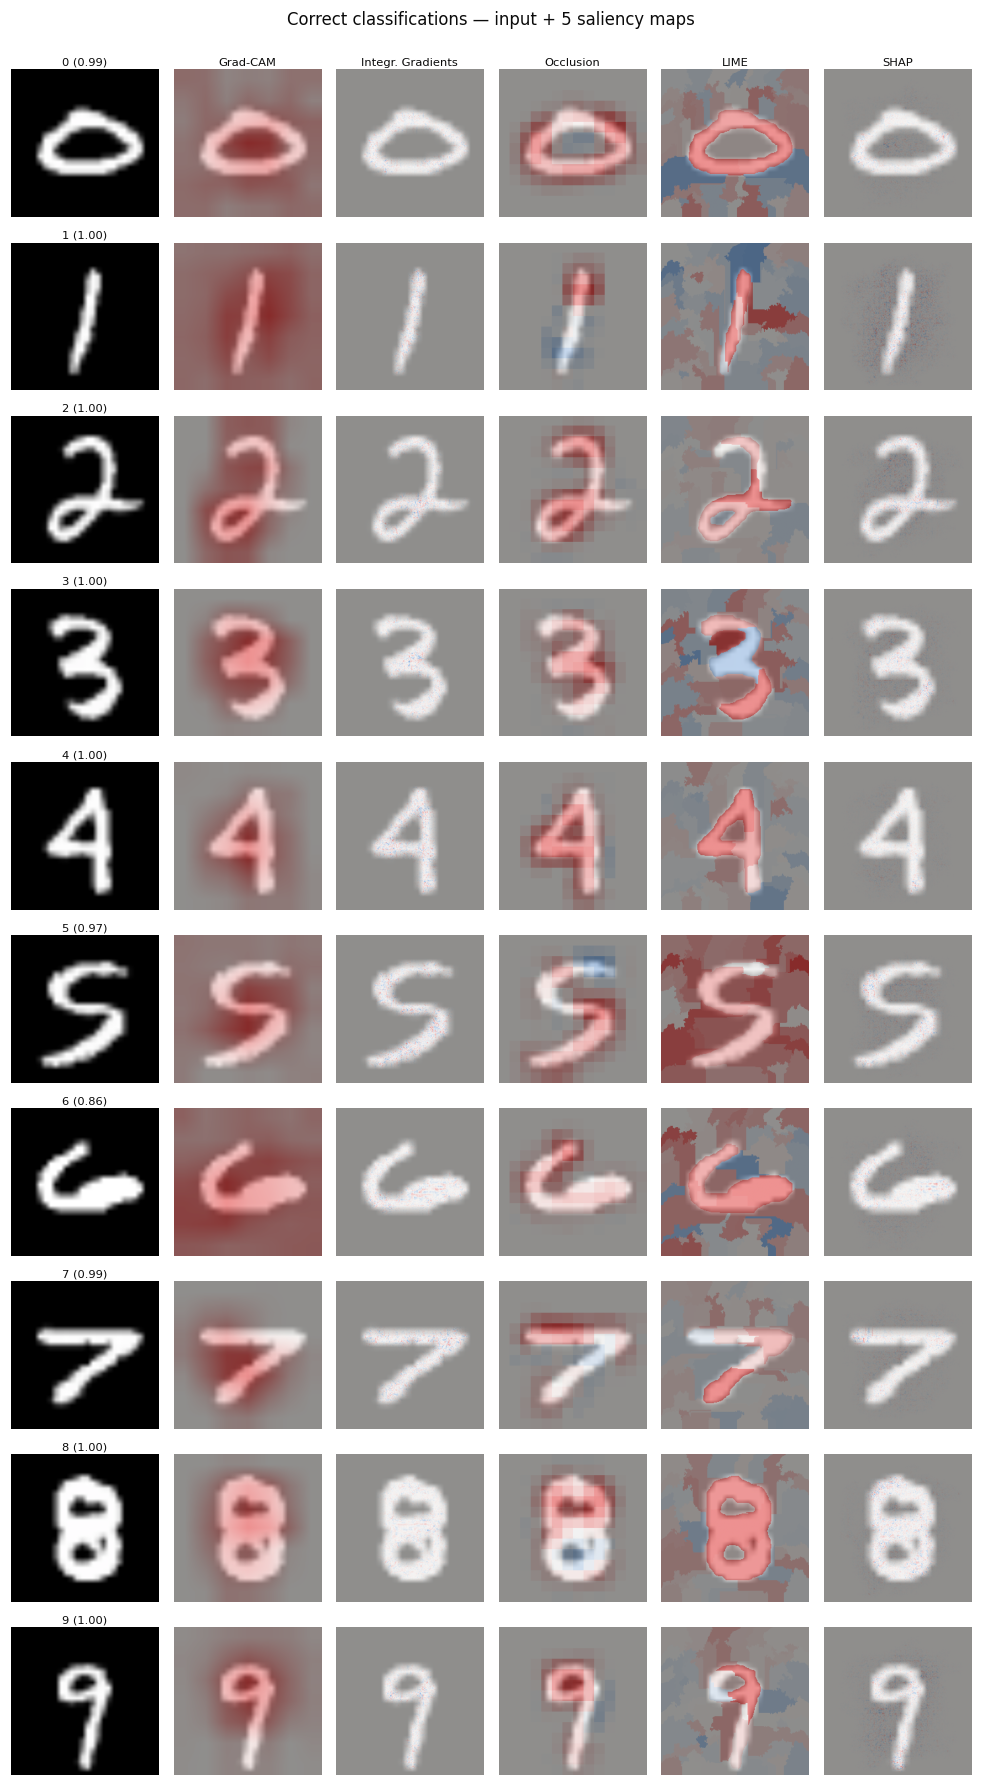

In [59]:
SALIENCY_CMAP = LinearSegmentedColormap.from_list("bv_signed", [COLOR_TRAIN, "#f0efec", COLOR_ERROR])


def case_label(case: dict) -> str:
    """Short caption: the digit and confidence for a correct case, true→predicted for an error."""
    outcome = f"{case['true']}" if case["true"] == case["predicted"] \
        else f"{case['true']}→{case['predicted']}"
    return f"{outcome} ({case['confidence']:.2f})"


def plot_attribution(ax: plt.Axes, display_image: np.ndarray, attribution_map: np.ndarray,
                     title: str) -> None:
    """Draw one saliency overlay: grayscale digit under a signed heatmap on a symmetric scale."""
    limit = np.abs(attribution_map).max() or 1.0
    ax.imshow(display_image, cmap="gray")
    ax.imshow(attribution_map, cmap=SALIENCY_CMAP, vmin=-limit, vmax=limit, alpha=0.6)
    ax.set_title(title, fontsize=7.5, color=INK_PRIMARY, pad=3)
    ax.set_axis_off()


def plot_technique_comparison(row_indices: list[int], title: str) -> plt.Figure:
    """One row per case: the input image, then all five saliency maps side by side."""
    names = list(attributions)
    fig, axes = plt.subplots(len(row_indices), len(names) + 1,
                             figsize=(1.5 * (len(names) + 1), 1.62 * len(row_indices)))
    axes = np.atleast_2d(axes)
    for row, index in enumerate(row_indices):
        display_image = denormalize(case_images[index])
        axes[row, 0].imshow(display_image, cmap="gray")
        axes[row, 0].set_title(case_label(CASES[index]), fontsize=7.5, color=INK_PRIMARY, pad=3)
        axes[row, 0].set_axis_off()
        for column, name in enumerate(names, start=1):
            # Technique names label the first row only; every row shares the same column order.
            plot_attribution(axes[row, column], display_image, attributions[name][index],
                             TECHNIQUE_LABELS[name] if row == 0 else "")
    fig.suptitle(title, color=INK_PRIMARY, y=1.0)
    fig.tight_layout()
    return fig


# The first 10 cases are one correct example per digit (rank-major ordering from Phase 1).
fig = plot_technique_comparison(list(range(CFG.num_classes)),
                               "Correct classifications — input + 5 saliency maps")
save_figure(fig, "07_maps_correct")
plt.show()

Saved figures/08_maps_incorrect.png


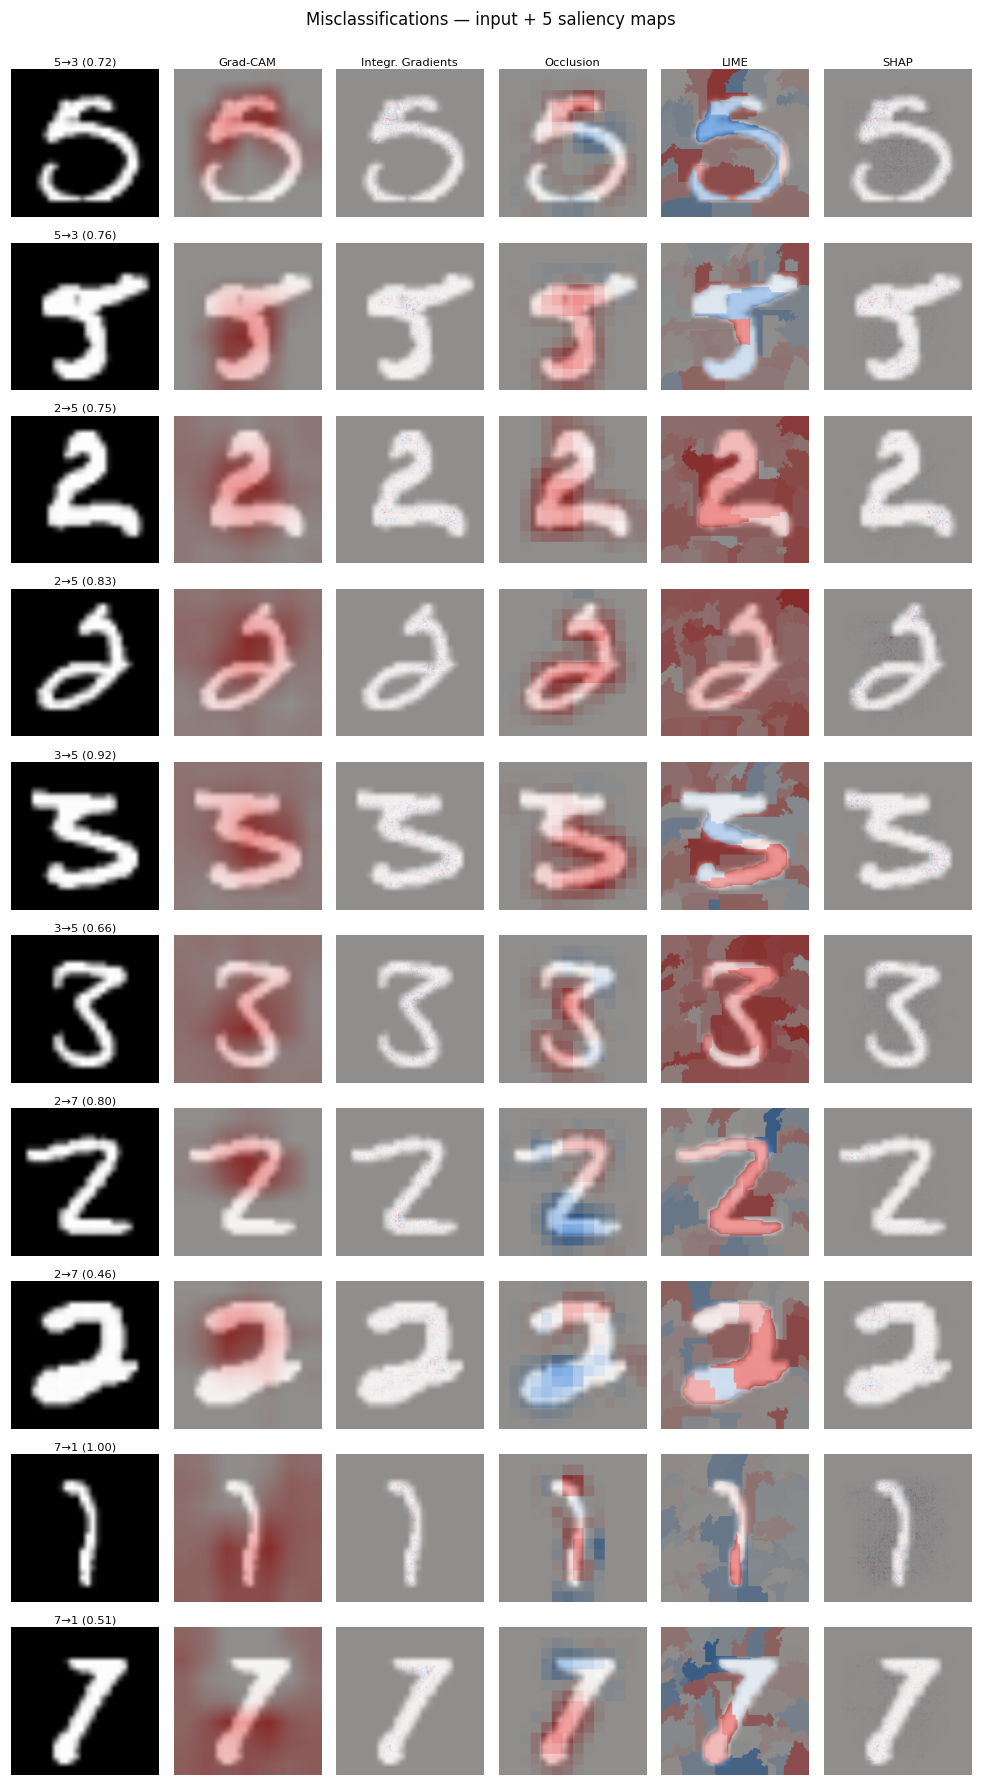

In [60]:
fig = plot_technique_comparison(list(range(len(correct_cases), len(CASES))),
                                "Misclassifications — input + 5 saliency maps")
save_figure(fig, "08_maps_incorrect")
plt.show()

## 10. Analysis

Three questions: how wrong the model is when it is wrong, what tips a decision to the wrong class,
and how far the five techniques agree.

### How wrong is the model when it is wrong?

Before looking at pixels, look at the probabilities. Errors delivered with high confidence would be
silent failures; errors delivered with low confidence are hesitations a bank can catch with a rule.

In [62]:
def error_profile(outputs: dict[str, np.ndarray]) -> pd.DataFrame:
    """Compare the probability output on the images the model gets right and the ones it gets wrong."""
    probabilities, labels = outputs["probabilities"], outputs["labels"]
    confidence = probabilities.max(axis=1)
    p_true = probabilities[np.arange(len(labels)), labels]
    rank_true = (probabilities > p_true[:, None]).sum(axis=1)  # 0 = the true class was predicted
    wrong = outputs["predictions"] != labels
    return pd.DataFrame({
        name: {
            "images": int(mask.sum()),
            "mean confidence": confidence[mask].mean(),
            "mean probability of true class": p_true[mask].mean(),
            "true class in top 2": (rank_true[mask] <= 1).mean(),
            "confidence below 0.90": (confidence[mask] < 0.9).mean(),
        }
        for name, mask in (("correct", ~wrong), ("wrong", wrong))
    })


def review_thresholds(outputs: dict[str, np.ndarray],
                      thresholds: tuple[float, ...] = (0.7, 0.8, 0.9, 0.95)) -> pd.DataFrame:
    """What a "send low-confidence images to a human" rule buys at each confidence threshold."""
    labels, predictions = outputs["labels"], outputs["predictions"]
    confidence = outputs["probabilities"].max(axis=1)
    wrong = predictions != labels
    rows = []
    for threshold in thresholds:
        flagged = confidence < threshold
        automatic = ~flagged
        rows.append({
            "threshold": threshold,
            "images flagged": flagged.mean(),
            "errors caught": wrong[flagged].sum() / wrong.sum(),
            "accuracy of the rest": (predictions[automatic] == labels[automatic]).mean(),
        })
    return pd.DataFrame(rows).set_index("threshold")


display(error_profile(test_outputs).round(3))
display(review_thresholds(test_outputs).round(4))

,correct,wrong
images,9726.000,274.000
mean confidence,0.978,0.680
mean probability of true class,0.978,0.206
true class in top 2,1.000,0.730
confidence below 0.90,0.062,0.861


,images flagged,errors caught,accuracy of the rest
threshold,,,
0.70,0.0338,0.5620,0.9876
0.80,0.0517,0.7153,0.9918
0.90,0.0837,0.8613,0.9959
0.95,0.1204,0.9161,0.9974


Saved figures/09_error_confidence.png


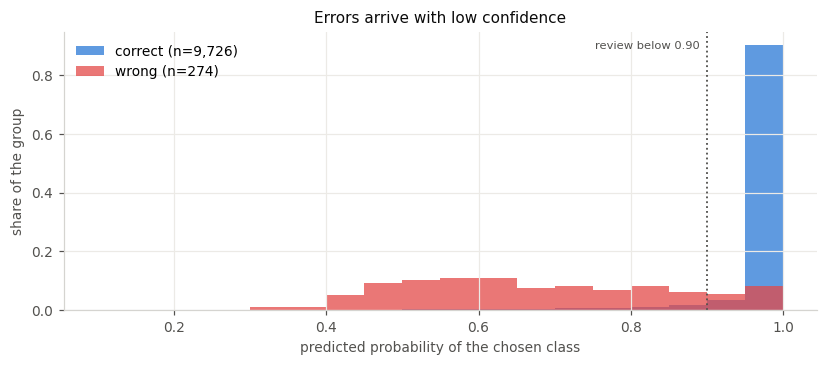

In [63]:
def plot_confidence(outputs: dict[str, np.ndarray], threshold: float = 0.9) -> plt.Figure:
    """Confidence distribution of correct and wrong predictions, each normalised within its group."""
    confidence = outputs["probabilities"].max(axis=1)
    wrong = outputs["predictions"] != outputs["labels"]
    bins = np.linspace(1 / outputs["probabilities"].shape[1], 1, 19)  # 1/n_classes is the floor

    fig, ax = plt.subplots(figsize=(7.6, 3.4))
    for label, mask, color in (("correct", ~wrong, COLOR_TRAIN), ("wrong", wrong, COLOR_ERROR)):
        ax.hist(confidence[mask], bins=bins, weights=np.full(int(mask.sum()), 1 / mask.sum()),
                color=color, alpha=0.75, label=f"{label} (n={int(mask.sum()):,})")
    ax.axvline(threshold, color=INK_MUTED, linestyle=":", linewidth=1.2)
    ax.annotate(f"review below {threshold:.2f}", xy=(threshold, ax.get_ylim()[1]), xytext=(-5, -6),
                textcoords="offset points", ha="right", va="top", fontsize=7.5, color=INK_MUTED)
    ax.set_xlabel("predicted probability of the chosen class")
    ax.set_ylabel("share of the group")
    ax.set_title("Errors arrive with low confidence", color=INK_PRIMARY)
    ax.legend()
    fig.tight_layout()
    return fig


fig = plot_confidence(test_outputs)
save_figure(fig, "09_error_confidence")
plt.show()

### What tips the decision to the wrong class?

Occlusion is run twice on each error: once for the predicted class, once for the true one. In those
two maps red means "this region supports that class", blue means "it argues against it". Their
difference attributes the gap `logit(predicted) − logit(true)` — the mistake itself — so in the last
column **red is what carried the wrong class and blue is what argued for the right one**.

In [64]:
def contrastive_occlusion(indices: list[int]) -> dict[str, np.ndarray]:
    """
    Occlusion maps for the predicted class, for the true class, and their difference.

    Same patch size and stride as the Phase 2 run, so the maps are directly comparable to figure 08.
    """
    images = case_images[indices]
    maps = {}
    explainer = Occlusion(model)
    for name in ("predicted", "true"):
        targets = torch.tensor([CASES[i][name] for i in indices], device=images.device)
        maps[name] = channel_sum(explainer.attribute(
            images, target=targets, baselines=black_baseline(images),
            sliding_window_shapes=(3, CFG.occlusion_window, CFG.occlusion_window),
            strides=(3, CFG.occlusion_stride, CFG.occlusion_stride),
            perturbations_per_eval=8,
        ))
    maps["difference"] = maps["predicted"] - maps["true"]
    return maps


CORRECT_ROWS = list(range(len(correct_cases)))
ERROR_ROWS = list(range(len(correct_cases), len(CASES)))

contrast_path = PATHS["attributions"] / "contrastive_occlusion.npz"
if contrast_path.exists():
    error_evidence = dict(np.load(contrast_path))
else:
    error_evidence = contrastive_occlusion(ERROR_ROWS)
    np.savez_compressed(contrast_path, **error_evidence)
print(f"Contrastive maps for {len(ERROR_ROWS)} errors: {error_evidence['difference'].shape}")

Contrastive maps for 10 errors: (10, 224, 224)


Saved figures/10_error_evidence.png


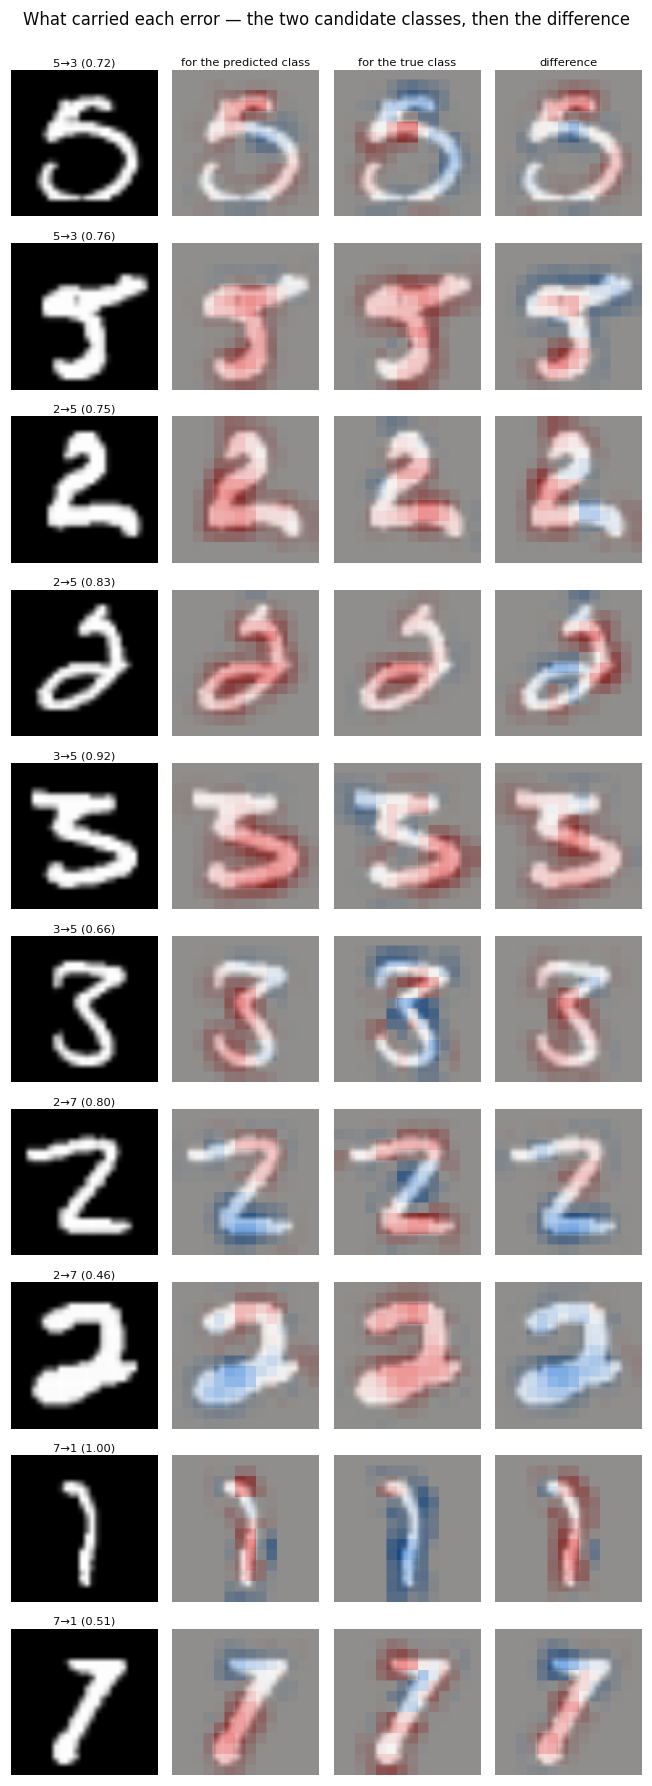

In [65]:
def plot_error_evidence(maps: dict[str, np.ndarray]) -> plt.Figure:
    """One row per error: the input, the evidence for each of the two candidate classes, the difference."""
    panels = [("predicted", "for the predicted class"), ("true", "for the true class"),
              ("difference", "difference")]
    fig, axes = plt.subplots(len(ERROR_ROWS), len(panels) + 1,
                             figsize=(1.5 * (len(panels) + 1), 1.62 * len(ERROR_ROWS)))
    for row, index in enumerate(ERROR_ROWS):
        display_image = denormalize(case_images[index])
        axes[row, 0].imshow(display_image, cmap="gray")
        axes[row, 0].set_title(case_label(CASES[index]), fontsize=7.5, color=INK_PRIMARY, pad=3)
        axes[row, 0].set_axis_off()
        for column, (key, label) in enumerate(panels, start=1):
            plot_attribution(axes[row, column], display_image, maps[key][row],
                             label if row == 0 else "")
    fig.suptitle("What carried each error — the two candidate classes, then the difference",
                 color=INK_PRIMARY, y=1.0)
    fig.tight_layout()
    return fig


fig = plot_error_evidence(error_evidence)
save_figure(fig, "10_error_evidence")
plt.show()

### Reading the errors

One story in five variations: **the evidence for the wrong class sits on the stroke the two digits
share, and the stroke that should separate them is missing, malformed, or simply outvoted.**

- **5→3**: the rounded part of the 5 is red for 3. Where the 5 does have a proper top bar, that bar
  comes out blue, read correctly as a 5, but loses anyway.
- **2→5 and 3→5**: the decision is made in the middle band, where 2, 3 and 5 are all the same curve
  turning right. In the 2→5 cases the closing base of the 2 is blue and gets overruled.
- **2→7** — the sharpest example: the diagonal top is red for 7, the horizontal base is distinctly blue,
  and most of the stroke evidence points at 2. The model registers that
  only a 2 has a base, and the top wins regardless.
- **7→1** — the vertical stroke is red for 1 along its whole length. The 0.997-confidence case is written
  with no crossing bar at all, and the maps show essentially no counter-evidence.

**Why this happens.** The backbone is frozen ImageNet DenseNet-121 and only a linear head was trained,
so digits have to be separated with features built for natural-image texture, never for stroke topology. Fine-tuning the last dense block, rather than freezing it, is the change that would address this.

### Alternative: explainable by design

Post-hoc explanation is not the only option. For Banca Virtuosa where a decision is high-stakes and the features are well-understood, an explainable-by-design model removes a whole class of audit risk. Where the task needs a deep network, post-hoc XAI is the fallback.

Other possibilities are worth weighing before committing to one for a compliance-grade classifier:

- **Shallow decision tree**: a single path of learned rule splits on *handcrafted features*; simplest possible artifact, a decision is one readable rule chain. *Fragile*: a small feature change can send a case down a completely different path; caps around 85–92% on MNIST-style tasks
- **Explainable Boosting Machine (EBM)**: Sum of per-feature shape functions, plus a handful of learned pairwise interaction terms. *Exact, not approximate*: the explanation is the model, not an estimate of it; scales to dozens of handcrafted features without losing readability; typically closes part of the accuracy gap left by a single tree. Shape functions stay meaningful only if the input features do, raw pixels work but read less clearly than "ink density per region". Interaction search *adds training cost*.
- **Neural Additive Model (NAM)**: Sum of small per-feature neural subnetworks, trained end-to-end. Same *additive exactness* as an EBM, but fits naturally into an existing PyTorch training loop; smooth, differentiable shape functions. *Fussier to train*: needs feature dropout / output penalties to keep shape functions from overfitting into noisy curves;
- **Prototype-based network** (e.g. ProtoPNet): Classifies by similarity to a bank of learned training-image patches: "this looks like part of that prototype". *Explanation is visual and case-based*, closer to how a human would justify a digit reading; can reach *CNN-level accuracy*. The explanation is a resemblance claim, not a numeric attribution; still a neural network under the hood, so *less of a glass box than a tree or a GAM*.

For Banca Virtuosa specifically, the EBM sits closest to the spot the decision tree was reaching
for: same handcrafted-feature philosophy, but "one rule chain" becomes "one additive graph per
feature," and a single case's prediction breaks down into a feature-by-feature waterfall an auditor
could re-derive by hand.